In [24]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras.models import Model
from keras.layers import LSTM, Activation, Dense, Dropout, Input, Embedding
from keras.optimizers import Adam
from keras.src.legacy.preprocessing.text import Tokenizer
from keras.utils import pad_sequences
from keras.callbacks import EarlyStopping
%matplotlib inline

In [25]:
df = pd.read_csv('spam.csv', delimiter=',', encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [26]:
df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1, inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   v1      5572 non-null   str  
 1   v2      5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


Text(0.5, 1.0, 'Number of ham and spam messages')

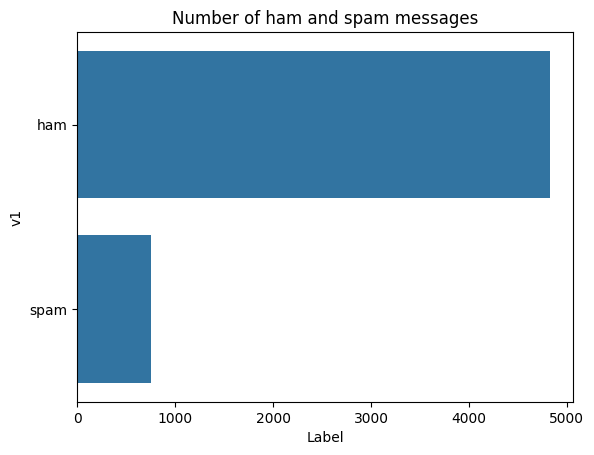

In [27]:
sns.countplot(df.v1)
plt.xlabel('Label')
plt.title('Number of ham and spam messages')

In [28]:
X = df.v2
Y = df.v1
le = LabelEncoder()
Y = le.fit_transform(Y)
Y = Y.reshape(-1, 1)

In [29]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.15)

In [30]:
max_words = 1000
max_len = 150
tok = Tokenizer(num_words=max_words)
tok.fit_on_texts(X_train)
sequences = tok.texts_to_sequences(X_train)
sequences_matrix = pad_sequences(sequences, maxlen=max_len)

In [31]:
def RNN():
    inputs = Input(name='inputs', shape=[max_len])
    layer = Embedding(max_words, 50, input_length=max_len)(inputs)
    layer = LSTM(64)(layer)
    layer = Dense(512, name='FC1')(layer)
    layer = Activation('relu')(layer)
    layer = Dropout(0.5)(layer)
    layer = Dense(1, name='out_layer')(layer)
    layer = Activation('sigmoid')(layer)
    model = Model(inputs=inputs, outputs=layer)
    return model

In [40]:
model = RNN()
model.summary()
model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=1e-3), metrics=['accuracy'])

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inputs (InputLayer)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_3 (Embedding)         │ (None, 150, 50)        │        50,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC1 (Dense)                     │ (None, 512)            │        33,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ out_layer (Dense)               │ (None, 1)              │           513 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113,233 (442.32 KB)

 Trainable params: 113,233 (442.32 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
model.fit(sequences_matrix, Y_train, batch_size=128, epochs=10,
          validation_split=0.2,
          callbacks=[EarlyStopping(monitor='val_loss', min_delta=0.0001)])

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 667ms/step - accuracy: 0.8574 - loss: 0.4263 - val_accuracy: 0.8745 - val_loss: 0.1990
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 663ms/step - accuracy: 0.9607 - loss: 0.1281 - val_accuracy: 0.9895 - val_loss: 0.0457
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 659ms/step - accuracy: 0.9865 - loss: 0.0442 - val_accuracy: 0.9873 - val_loss: 0.0311
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 667ms/step - accuracy: 0.9923 - loss: 0.0259 - val_accuracy: 0.9895 - val_loss: 0.0331


In [42]:
test_sequences = tok.texts_to_sequences(X_test)
test_sequences_matrix = pad_sequences(test_sequences, maxlen=max_len)

In [43]:
accr = model.evaluate(test_sequences_matrix, Y_test)
print('Test set\n  Loss: {:0.3f}\n  Accuracy: {:0.3f}'.format(accr[0], accr[1]))

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.9844 - loss: 0.0709
Test set
  Loss: 0.071
  Accuracy: 0.984


In [36]:
from keras.layers import Lambda
from keras import ops


def RNN_onehot():
    inputs = Input(name='inputs', shape=[max_len], dtype='int32')
    layer = Lambda(
        lambda x: ops.one_hot(x, num_classes=max_words),
        output_shape=(max_len, max_words),
    )(inputs)
    layer = LSTM(64)(layer)
    layer = Dense(256, name='FC1')(layer)
    layer = Activation('relu')(layer)
    layer = Dropout(0.5)(layer)
    layer = Dense(1, name='out_layer')(layer)
    layer = Activation('sigmoid')(layer)
    return Model(inputs=inputs, outputs=layer)

In [37]:
model_oh = RNN_onehot()
model_oh.summary()
model_oh.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=1e-3), metrics=['accuracy'])

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inputs (InputLayer)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, 150, 1000)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │       272,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC1 (Dense)                     │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ out_layer (Dense)               │ (None, 1)              │           257 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289,537 (1.10 MB)

 Trainable params: 289,537 (1.10 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
model_oh.fit(sequences_matrix, Y_train, batch_size=128, epochs=10,
             validation_split=0.2,
             callbacks=[EarlyStopping(monitor='val_loss', min_delta=0.0001)])

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 24s 791ms/step - accuracy: 0.8524 - loss: 0.4399 - val_accuracy: 0.8745 - val_loss: 0.2607
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 27s 919ms/step - accuracy: 0.9224 - loss: 0.1943 - val_accuracy: 0.9800 - val_loss: 0.0854
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 25s 824ms/step - accuracy: 0.9839 - loss: 0.0647 - val_accuracy: 0.9926 - val_loss: 0.0384
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 24s 814ms/step - accuracy: 0.9559 - loss: 0.1292 - val_accuracy: 0.9800 - val_loss: 0.0719


In [39]:
accr_oh = model_oh.evaluate(test_sequences_matrix, Y_test)
print('Test set (one-hot)\n  Loss: {:0.3f}\n  Accuracy: {:0.3f}'.format(accr_oh[0], accr_oh[1]))

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.9725 - loss: 0.0919
Test set (one-hot)
  Loss: 0.092
  Accuracy: 0.972
